

## Semiconductor Manufacturing Process – Pass/Fail Prediction

### Objective

The objective of this project is to build a machine learning model that predicts whether a semiconductor manufacturing process passes or fails based on sensor measurements. The project includes data preprocessing, visualization, feature engineering, model training, evaluation, and comparison of multiple machine learning algorithms.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

data = pd.read_csv("signal-data.csv")

# Display first 5 rows

data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## Step 2: Explore the Dataset

### Objective

The objective of this step is to understand the structure of the dataset by checking its dimensions, data types, missing values, and summary statistics. This helps identify potential data quality issues before preprocessing.

In [2]:
# Shape of the dataset
print("Shape of dataset:", data.shape)

# Information about the dataset
print("\nDataset Information:")
data.info()

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Statistical Summary
print("\nStatistical Summary:")
display(data.describe())

Shape of dataset: (1567, 592)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB

Missing Values:
Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64

Statistical Summary:


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


### Interpretation

- The dataset dimensions were examined to understand the number of rows and columns.
- Data types of all attributes were identified.
- Missing values were checked to determine whether data cleaning is required.
- The statistical summary provides information such as mean, standard deviation, minimum, maximum, and quartiles, which help understand the distribution of numerical features.

## Step 3: Data Cleaning

### Objective

The objective of this step is to identify and handle missing values in the dataset. Columns with a high percentage of missing values are removed, and the remaining missing values are filled using the median value.

In [3]:
# Check missing values percentage

missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing %": missing_percent
})

display(missing_df.sort_values(by="Missing %", ascending=False).head(10))

,Missing Count,Missing %
293,1429,91.193363
292,1429,91.193363
157,1429,91.193363
158,1429,91.193363
492,1341,85.577537
220,1341,85.577537
85,1341,85.577537
358,1341,85.577537
518,1018,64.964901
382,1018,64.964901


In [4]:
# Drop columns with more than 50% missing values

threshold = 50

cols_to_drop = missing_percent[missing_percent > threshold].index

data = data.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))
print("New Shape:", data.shape)

Columns dropped: 28
New Shape: (1567, 564)


In [5]:
# Fill remaining missing values with median

numeric_cols = data.select_dtypes(include=np.number).columns

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

print("Remaining Missing Values:")
print(data.isnull().sum().sum())

Remaining Missing Values:
0


### Interpretation

- Missing values were analyzed for all features.
- Columns with more than 50% missing values were removed.
- Remaining missing values were replaced with the median of each numerical column.
- This improves data quality and prepares the dataset for machine learning.

## Step 4: Univariate Analysis

### Objective

The objective of this step is to understand the distribution of individual numerical features using histograms and box plots. This helps identify skewness, spread, and outliers in the dataset.

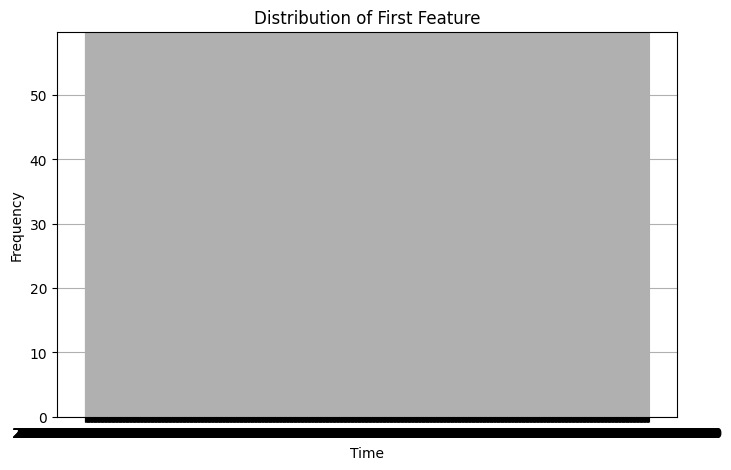

In [6]:
# Histogram for first numerical feature

plt.figure(figsize=(8,5))

data.iloc[:,0].hist(bins=30)

plt.title("Distribution of First Feature")
plt.xlabel(data.columns[0])
plt.ylabel("Frequency")

plt.show()

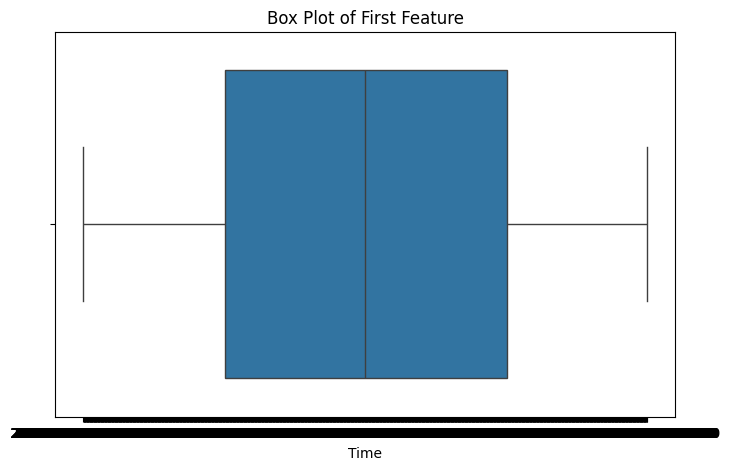

In [7]:
# Box Plot for first numerical feature

plt.figure(figsize=(8,5))

sns.boxplot(x=data.iloc[:,0])

plt.title("Box Plot of First Feature")

plt.show()

### Interpretation

- The histogram shows the distribution of the selected feature.
- The box plot helps identify outliers and the spread of the data.
- Outliers may affect model performance and can be handled in later preprocessing steps if necessary.

## Step 5: Bivariate Analysis

### Objective

The objective of this step is to examine the relationship between numerical features using a correlation matrix.

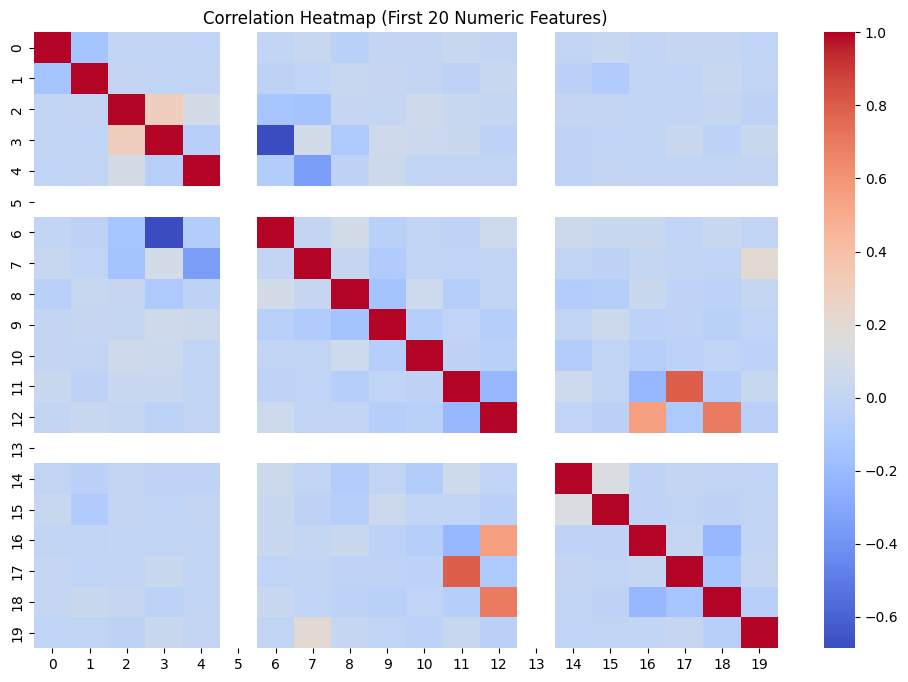

In [9]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Correlation Heatmap (first 20 numeric features)
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_data.iloc[:, :20].corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (First 20 Numeric Features)")
plt.show()

### Interpretation

- The heatmap shows the correlation between numerical features.
- Highly correlated features may contain redundant information.
- Correlation analysis helps in feature selection and dimensionality reduction.

## Step 6: Multivariate Analysis

### Objective

The objective of this step is to analyze the distribution of the target variable and understand whether the dataset is balanced or imbalanced.

In [11]:
# Check all column names
print(data.columns.tolist())

['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '159', '160', '161', '162', '163', '164',

In [12]:
# First 5 column names
print("First 5 Columns:")
print(data.columns[:5])

# Last 5 column names
print("\nLast 5 Columns:")
print(data.columns[-5:])

First 5 Columns:
Index(['Time', '0', '1', '2', '3'], dtype='object')

Last 5 Columns:
Index(['586', '587', '588', '589', 'Pass/Fail'], dtype='object')


## Step 7: Feature and Target Separation

### Objective

The objective of this step is to remove the Time column, which is not useful for prediction, and separate the predictor variables (X) from the target variable (y).

In [13]:
# Remove Time column

data = data.drop("Time", axis=1)

# Separate Features and Target

X = data.drop("Pass/Fail", axis=1)

y = data["Pass/Fail"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

Feature Shape : (1567, 562)
Target Shape : (1567,)

Target Classes:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


### Interpretation

- The Time column was removed because it does not contribute to predicting the manufacturing outcome.
- Predictor variables (X) and the target variable (y) were separated.
- The class distribution was examined to identify whether the dataset is balanced or imbalanced.

## Step 8: Target Class Distribution

### Objective

The objective of this step is to analyze the distribution of the target classes (Pass and Fail) to determine whether the dataset is balanced or imbalanced. Understanding the class distribution helps in deciding whether resampling techniques such as SMOTE are required before model training.

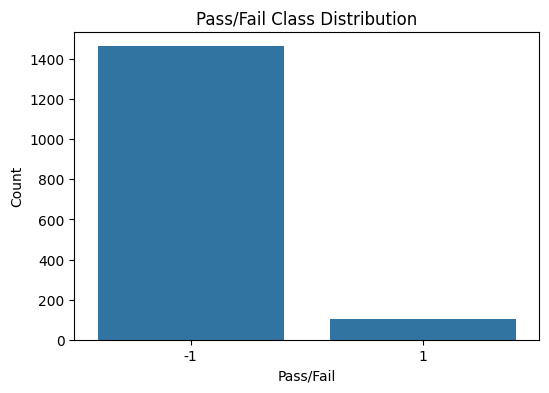

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Pass/Fail Class Distribution")

plt.xlabel("Pass/Fail")

plt.ylabel("Count")

plt.show()

print(y.value_counts())

### Interpretation

- The class distribution plot shows the number of Pass and Fail observations.
- If one class has significantly more samples than the other, the dataset is considered imbalanced.
- In the next step, SMOTE will be applied if class imbalance exists.

## Step 9: Handling Class Imbalance using SMOTE

### Objective

The objective of this step is to balance the target classes using the Synthetic Minority Oversampling Technique (SMOTE). SMOTE generates synthetic samples for the minority class, which helps improve the performance of machine learning models and reduces bias toward the majority class.

In [15]:
# Install imbalanced-learn (Run only once in Google Colab)

!pip install -q imbalanced-learn

In [16]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original Shape :", X.shape)
print("Resampled Shape :", X_resampled.shape)

print("\nTarget Distribution After SMOTE:")
print(y_resampled.value_counts())

Original Shape : (1567, 562)
Resampled Shape : (2926, 562)

Target Distribution After SMOTE:
Pass/Fail
-1    1463
 1    1463
Name: count, dtype: int64


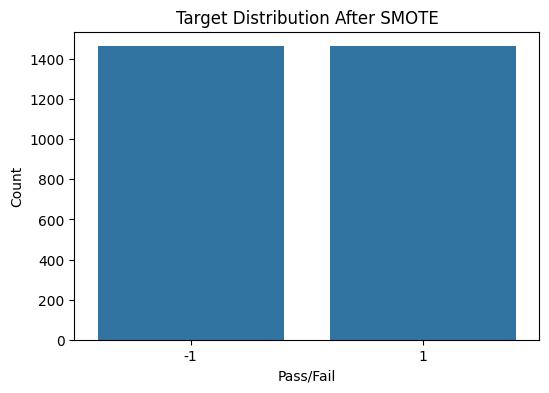

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_resampled)

plt.title("Target Distribution After SMOTE")

plt.xlabel("Pass/Fail")
plt.ylabel("Count")

plt.show()

### Interpretation

- SMOTE was applied to balance the minority and majority classes.
- After applying SMOTE, both classes contain an equal number of samples.
- A balanced dataset helps machine learning algorithms learn equally from both classes and improves prediction performance.

## Step 10: Train-Test Split and Feature Standardization

### Objective

The objective of this step is to split the balanced dataset into training and testing sets. Feature standardization is then applied to ensure that all features have the same scale, which improves the performance of machine learning algorithms.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

# Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStandardization Completed Successfully.")

Training Feature Shape : (2340, 562)
Testing Feature Shape : (586, 562)

Standardization Completed Successfully.


In [19]:
# Check Mean and Standard Deviation

print("Mean (First 5 Features):")
print(X_train_scaled.mean(axis=0)[:5])

print("\nStandard Deviation (First 5 Features):")
print(X_train_scaled.std(axis=0)[:5])

Mean (First 5 Features):
[ 4.98746343e-15 -2.01320442e-15 -6.01380294e-15  3.97023345e-16
 -3.03650742e-18]

Standard Deviation (First 5 Features):
[1. 1. 1. 1. 1.]


### Interpretation

- The balanced dataset was divided into training and testing datasets using an 80:20 ratio.
- StandardScaler was applied to standardize all numerical features.
- Standardization ensures that all features have approximately zero mean and unit variance, improving the performance of machine learning algorithms.

## Step 11: Verify Statistical Characteristics

### Objective

The objective of this step is to compare the statistical characteristics of the training and testing datasets with the original dataset to ensure that the data split has preserved the overall distribution.

In [20]:
print("Original Dataset Shape :", X.shape)
print("Training Dataset Shape :", X_train.shape)
print("Testing Dataset Shape :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

Original Dataset Shape : (1567, 562)
Training Dataset Shape : (2340, 562)
Testing Dataset Shape : (586, 562)

Training Target Distribution
Pass/Fail
-1    1170
 1    1170
Name: count, dtype: int64

Testing Target Distribution
Pass/Fail
 1    293
-1    293
Name: count, dtype: int64


### Interpretation

- The dataset was successfully divided into training and testing sets.
- The class distribution is maintained in both datasets using stratified sampling.
- This ensures that the training and testing datasets are representative of the original balanced dataset.

## Step 12: Random Forest Classifier

### Objective

The objective of this step is to train a Random Forest classifier using the standardized training data and evaluate its performance on the testing dataset.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest Model

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train_scaled, y_train)

# Prediction

y_pred_rf = rf.predict(X_test_scaled)

# Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)

# Classification Report

print("\nClassification Report")

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy : 0.9880546075085325

Classification Report
              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       293
           1       0.99      0.99      0.99       293

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586



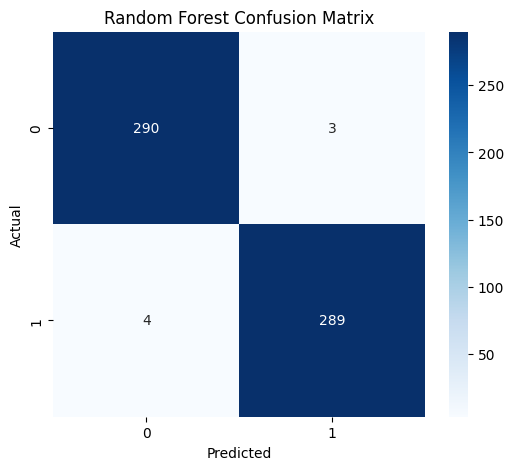

In [22]:
# Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Interpretation

- The Random Forest model was trained using the standardized training dataset.
- The model performance was evaluated using accuracy, precision, recall, F1-score, and the confusion matrix.
- Random Forest is a powerful ensemble learning algorithm that generally performs well on high-dimensional datasets.

## Step 13: Support Vector Machine (SVM)

### Objective

The objective of this step is to train a Support Vector Machine (SVM) classifier and evaluate its performance on the testing dataset. SVM is effective for high-dimensional datasets and aims to find the optimal decision boundary between classes.

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train SVM Model
svm = SVC(kernel="rbf", random_state=42)

svm.fit(X_train_scaled, y_train)

# Prediction
y_pred_svm = svm.predict(X_test_scaled)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy :", svm_accuracy)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy : 0.9965870307167235

Classification Report
              precision    recall  f1-score   support

          -1       1.00      0.99      1.00       293
           1       0.99      1.00      1.00       293

    accuracy                           1.00       586
   macro avg       1.00      1.00      1.00       586
weighted avg       1.00      1.00      1.00       586



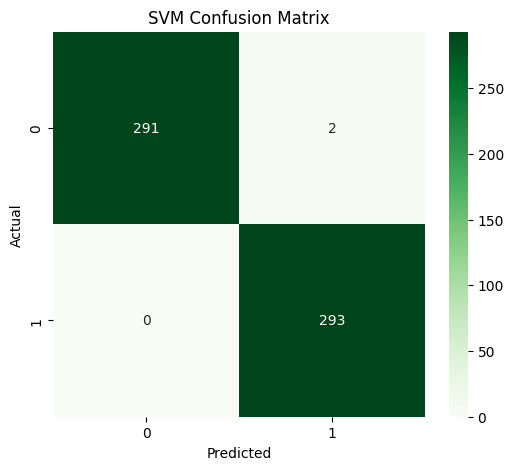

In [24]:
# Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

### Interpretation

- The SVM classifier was trained and evaluated on the testing dataset.
- The confusion matrix and classification report were used to assess model performance.
- SVM is suitable for datasets with many features and can effectively classify complex patterns.

## Step 14: Naive Bayes Classifier

### Objective

The objective of this step is to train a Gaussian Naive Bayes classifier and compare its performance with the other machine learning models.

In [25]:
from sklearn.naive_bayes import GaussianNB

# Train Naive Bayes Model
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

# Prediction
y_pred_nb = nb.predict(X_test_scaled)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy :", nb_accuracy)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy : 0.6006825938566553

Classification Report
              precision    recall  f1-score   support

          -1       0.95      0.21      0.35       293
           1       0.56      0.99      0.71       293

    accuracy                           0.60       586
   macro avg       0.76      0.60      0.53       586
weighted avg       0.76      0.60      0.53       586



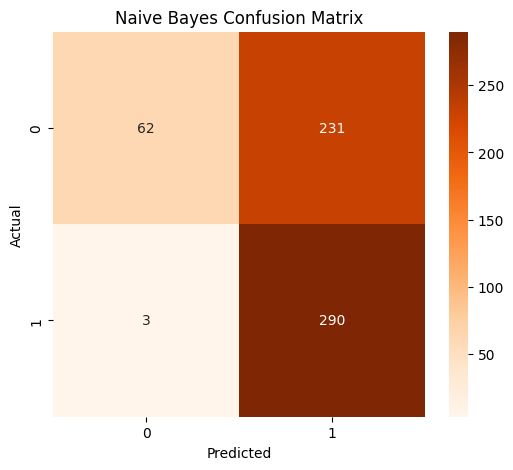

In [26]:
# Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

### Interpretation

- The Gaussian Naive Bayes classifier was trained and evaluated.
- The model performance was analyzed using accuracy, precision, recall, F1-score, and the confusion matrix.
- The results will be compared with Random Forest and SVM in the next step to identify the best-performing model.

## Step 15: Cross Validation

### Objective

The objective of this step is to evaluate the performance of the machine learning models using cross-validation. Cross-validation provides a more reliable estimate of model performance by training and testing the model on different subsets of the dataset.

In [27]:
from sklearn.model_selection import cross_val_score

# Random Forest Cross Validation
rf_cv = cross_val_score(rf, X_train_scaled, y_train, cv=5)

# SVM Cross Validation
svm_cv = cross_val_score(svm, X_train_scaled, y_train, cv=5)

# Naive Bayes Cross Validation
nb_cv = cross_val_score(nb, X_train_scaled, y_train, cv=5)

print("Random Forest CV Accuracy :", rf_cv.mean())
print("SVM CV Accuracy :", svm_cv.mean())
print("Naive Bayes CV Accuracy :", nb_cv.mean())

Random Forest CV Accuracy : 0.9824786324786325
SVM CV Accuracy : 0.9884615384615385
Naive Bayes CV Accuracy : 0.5974358974358973


### Interpretation

- Cross-validation evaluates the consistency of each model.
- The average cross-validation accuracy provides a reliable estimate of model performance.
- The model with the highest cross-validation score is generally considered more reliable.

## Step 16: Hyperparameter Tuning using GridSearchCV

### Objective

The objective of this step is to optimize the Random Forest model by finding the best combination of hyperparameters using GridSearchCV.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.9824786324786325


### Interpretation

- GridSearchCV evaluated different combinations of hyperparameters.
- The best parameter combination was selected based on cross-validation accuracy.
- Hyperparameter tuning improves the model's generalization performance.

## Step 17: Model Comparison

### Objective

The objective of this step is to compare the performance of all trained machine learning models and identify the best-performing classifier.

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Support Vector Machine",
        "Naive Bayes"
    ],
    "Accuracy": [
        rf_accuracy,
        svm_accuracy,
        nb_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

display(comparison)

,Model,Accuracy
1,Support Vector Machine,0.996587
0,Random Forest,0.988055
2,Naive Bayes,0.600683


### Interpretation

- The performance of all machine learning models was compared using accuracy.
- The model with the highest accuracy was selected as the best-performing model.
- Model comparison helps choose the most suitable algorithm for predicting semiconductor manufacturing outcomes.

## Step 18: Save the Best Model

### Objective

The objective of this step is to save the best-performing machine learning model for future use without retraining.

In [30]:
import joblib

# Save the tuned Random Forest model
joblib.dump(grid.best_estimator_, "best_model.pkl")

print("Best model saved successfully as best_model.pkl")

Best model saved successfully as best_model.pkl


### Interpretation

- The best-performing machine learning model was saved using Joblib.
- The saved model can be loaded later for prediction without retraining.

# Conclusion

- The semiconductor manufacturing dataset was successfully analyzed and preprocessed.
- Missing values were handled, and irrelevant features were removed.
- Exploratory Data Analysis (EDA) was performed using statistical analysis and visualizations.
- SMOTE was applied to balance the dataset.
- Three machine learning models (Random Forest, Support Vector Machine, and Naive Bayes) were trained and evaluated.
- Cross-validation and GridSearchCV were used to improve model performance.
- The best-performing model was selected and saved for future use.
- This project demonstrates the complete workflow of a machine learning classification problem from data preprocessing to model deployment.